# GDF Viewer for VS Code

Open this notebook in VS Code, select the `cosmos` Python kernel, and run the cells. Choose a recording from the dropdown, then rerun the cells below the picker to inspect it. Files are opened read-only with `preload=False`.

In [236]:
from pathlib import Path
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt
import mne
import pandas as pd
from IPython.display import display

search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
PROJECT_ROOT = next(
    (
        root
        for root in search_roots
        if (root / "notebooks").is_dir() and (root / "data").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from inside the bci_cleaning project")

data_candidates = [
    PROJECT_ROOT / "data" / "processed",
    PROJECT_ROOT / "data" / "raw" / "BCI Database",
    PROJECT_ROOT / "data" / "raw",
]
DATA_ROOT = next(
    (root for root in data_candidates if root.is_dir() and any(root.rglob("*.gdf"))),
    None,
)
if DATA_ROOT is None:
    raise FileNotFoundError("No GDF recordings were found in data/processed or data/raw")

gdf_files = sorted(DATA_ROOT.rglob("*.gdf"))
print(f"Found {len(gdf_files)} GDF recordings in {DATA_ROOT.relative_to(PROJECT_ROOT)}")

Found 694 GDF recordings in data/processed


In [237]:
gdf_picker = widgets.Dropdown(
    options=[(path.relative_to(DATA_ROOT).as_posix(), str(path)) for path in gdf_files],
    description="Recording:",
    layout=widgets.Layout(width="95%"),
    style={"description_width": "initial"},
)
display(gdf_picker)

Dropdown(description='Recording:', layout=Layout(width='95%'), options=(('Signals/DATA A/A1/A1_CE_baseline.gdf…

After changing the recording above, run this cell and the remaining cells again.

In [238]:
selected_gdf = Path(gdf_picker.value)
raw = mne.io.read_raw_gdf(selected_gdf, preload=False, verbose="ERROR")

summary = pd.Series(
    {
        "file": selected_gdf.relative_to(DATA_ROOT).as_posix(),
        "channels": raw.info["nchan"],
        "sampling_frequency_hz": raw.info["sfreq"],
        "samples": raw.n_times,
        "duration_seconds": raw.times[-1],
        "annotations": len(raw.annotations),
        "preloaded": raw.preload,
    },
    name="value",
)
summary.to_frame()

,value
file,Signals/DATA A/A1/A1_CE_baseline.gdf
channels,32
sampling_frequency_hz,512.0
samples,95776
duration_seconds,187.060547
annotations,7
preloaded,False


In [239]:
channel_table = pd.DataFrame(
    {
        "channel": raw.ch_names,
        "type": raw.get_channel_types(),
    }
)
channel_table

,channel,type
0,Fz,eeg
1,FCz,eeg
2,Cz,eeg
3,CPz,eeg
4,Pz,eeg
5,C1,eeg
6,C3,eeg
7,C5,eeg
8,C2,eeg
9,C4,eeg


In [240]:
annotation_table = pd.DataFrame(
    {
        "onset_seconds": raw.annotations.onset,
        "duration_seconds": raw.annotations.duration,
        "description": raw.annotations.description,
    }
)
annotation_table


,onset_seconds,duration_seconds,description
0,0.0,0.001953,32769
1,5.0,0.001953,32775
2,5.0,0.001953,786
3,5.0,0.001953,33282
4,185.0,0.001953,32776
5,185.0,0.001953,33282
6,187.0,0.001953,32770


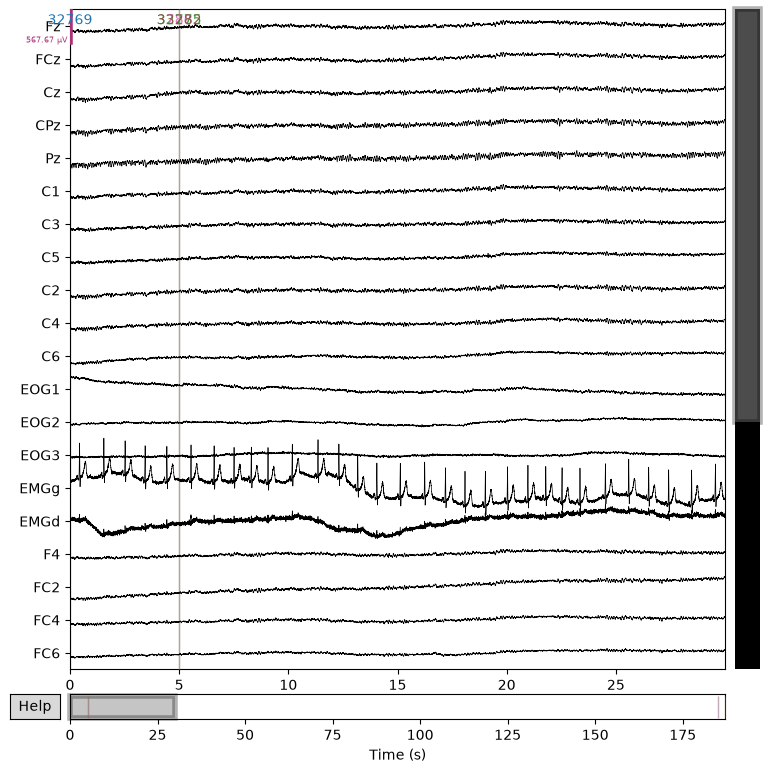

In [242]:
%matplotlib inline

plot_start_seconds = 0
plot_duration_seconds = min(30, raw.times[-1])
raw.plot(
    start=plot_start_seconds,
    duration=plot_duration_seconds,
    n_channels=min(20, raw.info["nchan"]),
    scalings="auto",
    show=False,
    block=False,
    title=selected_gdf.name,
)
plt.show()

In [251]:
performances_path = PROJECT_ROOT / "data" / "processed" / "Perfomances.csv"
performances = pd.read_csv(
    performances_path,
    sep=";",
    encoding="utf-8",
    skiprows=2,
)

performance_columns = ["Perf_RUN_3", "Perf_RUN_4", "Perf_RUN_5", "Perf_RUN_6"]
for column in performance_columns:
    performances[column] = pd.to_numeric(
        performances[column].astype("string").str.replace(",", ".", regex=False),
        errors="coerce",
    ).astype(float)

performances = performances.dropna(subset=["SUJ_gender", "EXP_gender", "Birth_year"])
performances = performances.drop(63)
performances = performances.drop(88)
performances["SUJ_gender"] = pd.to_numeric(performances["SUJ_gender"])
performances

,SUJ_ID,SUJ_gender,EXP_gender,COMMENTS,Perf_RUN_3,Perf_RUN_4,Perf_RUN_5,Perf_RUN_6,Birth_year,Vision,...,Q2,Q3,Q4,IM,EX,AX,TM,IN,SC,Interrogation
0,A1,1,1,NaN,67.5,92.5,95.0,82.5,1993,1,...,7,3,8,5,"4,7","9,1","3,1","3,6",3,15
1,A2,1,1,F3 Noisy,55.0,62.5,47.5,57.5,1993,1,...,6,3,5,2,"5,9","4,7","3,6","4,8","2,2",10
2,A3,2,1,NaN,100.0,95.0,97.5,100.0,1969,2,...,6,3,5,7,"5,5","4,2","4,8","3,3",4,7
3,A4,1,1,NaN,55.0,45.0,55.0,50.0,1982,2,...,7,2,7,3,"5,8","6,8",5,"4,9","2,4",8
4,A5,1,2,Baseline OE & R1 : outside noise. Changed FC5 ...,50.0,50.0,55.0,50.0,1985,2,...,8,5,8,4,"1,7","6,4","7,6","8,4","4,5",5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,B81,1,2,BL : CP5 noisy,60.0,50.0,47.5,62.5,1997,1,...,5,5,6,8,"7,7","3,9","4,4","6,3","3,7",NaN
89,C82,2,2,NaN,60.0,40.0,40.0,57.5,1995,1,...,5,1,1,3,"3,2",3,"9,4","0,9","3,2",8
91,C84,2,2,NaN,75.0,87.5,82.5,60.0,2001,1,...,4,1,6,4,"4,8",6,"10,9",1,3,8
93,C86,2,2,NaN,52.5,70.0,57.5,70.0,2000,1,...,3,1,6,2,"3,6","6,1",12,0,"3,8",4


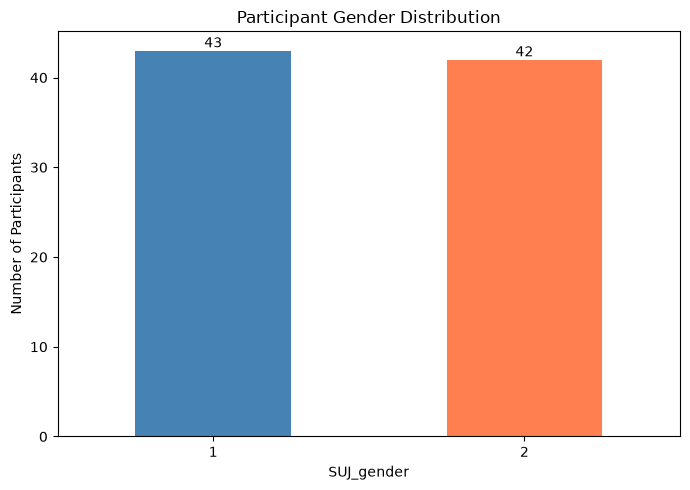

In [252]:
gender_counts = (
    performances["SUJ_gender"]
    .value_counts()
    .reindex([1, 2], fill_value=0)
    .astype(int)
)

ax = gender_counts.plot.bar(
    color=["steelblue", "coral"],
    figsize=(7, 5),
    rot=0,
)
ax.set_title("Participant Gender Distribution")
ax.set_xlabel("SUJ_gender")
ax.set_ylabel("Number of Participants")
ax.set_xticklabels(["1", "2"])
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

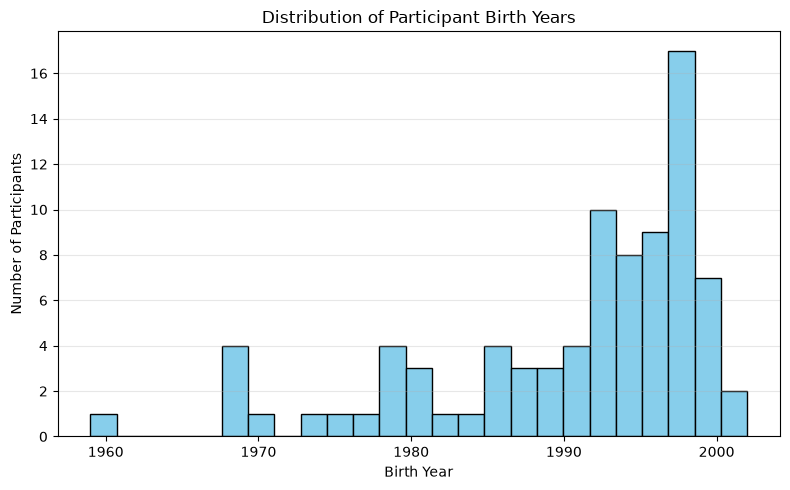

In [265]:
birth = performances["Birth_year"].astype(int)

plt.figure(figsize=(8, 5))
plt.hist(birth, bins=25, color="skyblue", edgecolor="black")
plt.title("Distribution of Participant Birth Years")
plt.xlabel("Birth Year")
plt.ylabel("Number of Participants")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

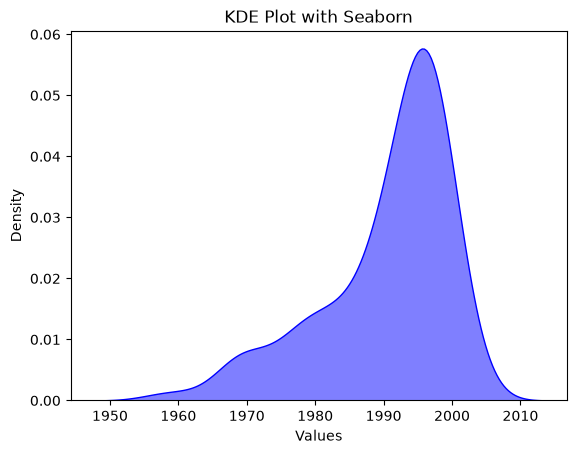

In [258]:
import seaborn as sns

sns.kdeplot(birth, fill=True, color="blue", alpha=0.5)
plt.title("KDE Plot with Seaborn")
plt.xlabel("Values")
plt.ylabel("Density")
plt.show()


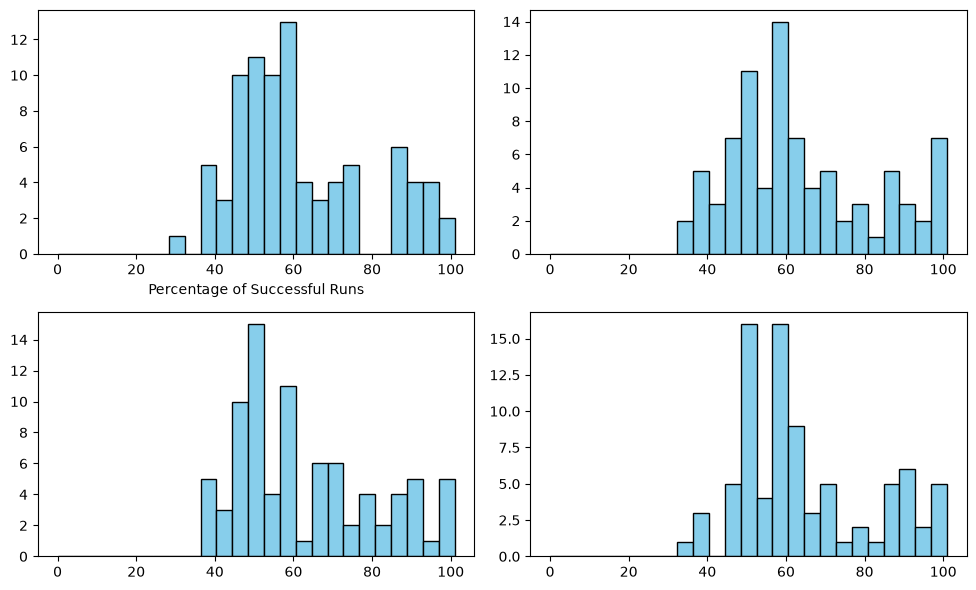

'\ndf = pd.DataFrame({\n    \'Year\': [2019, 2020, 2021, 2022],\n    \'Sales_A\': [120, 135, 150, 160],\n    \'Sales_B\': [80, 95, 100, 120],\n    \'Profit_A\': [30, 32, 36, 38],\n    \'Profit_B\': [18, 20, 22, 26]\n})\n\nfig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)\n\n# [0, 0] Sales of A\naxs[0, 0].bar(df[\'Year\'], df[\'Sales_A\'], color=\'steelblue\')\naxs[0, 0].set_title("Sales - Product A")\n\n# [0, 1] Sales of B\naxs[0, 1].bar(df[\'Year\'], df[\'Sales_B\'], color=\'salmon\')\naxs[0, 1].set_title("Sales - Product B")\n\n# [1, 0] Profit of A\naxs[1, 0].plot(df[\'Year\'], df[\'Profit_A\'], color=\'seagreen\', marker=\'o\')\naxs[1, 0].set_title("Profit - Product A")\n\n# [1, 1] Profit of B\naxs[1, 1].plot(df[\'Year\'], df[\'Profit_B\'], color=\'orange\', marker=\'o\')\naxs[1, 1].set_title("Profit - Product B")\n\n\nfor ax in axs[1, :]:\n    ax.set_xticks(df[\'Year\'])\n    ax.set_xticklabels(df[\'Year\'])\n\nfor ax in axs[:, 0]:   \n    ax.set_ylabel("Amou

In [275]:
fig, axes = plt.subplots(2, 2, figsize = (10,6))
axes[0,0].hist(performances["Perf_RUN_3"], bins = 25,range=(0, 101),color = "skyblue", edgecolor = "black")
axes[0,0].set_xlabel("Percentage of Successful Runs")
axes[0,1].hist(performances["Perf_RUN_4"], bins = 25,range=(0, 101), color = "skyblue", edgecolor = "black")

axes[1,0].hist(performances["Perf_RUN_5"], bins = 25,range=(0, 101), color = "skyblue", edgecolor = "black")

axes[1,1].hist(performances["Perf_RUN_6"], bins = 25,range=(0, 101), color = "skyblue", edgecolor = "black")
plt.tight_layout()
plt.show()
'''
df = pd.DataFrame({
    'Year': [2019, 2020, 2021, 2022],
    'Sales_A': [120, 135, 150, 160],
    'Sales_B': [80, 95, 100, 120],
    'Profit_A': [30, 32, 36, 38],
    'Profit_B': [18, 20, 22, 26]
})

fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)

# [0, 0] Sales of A
axs[0, 0].bar(df['Year'], df['Sales_A'], color='steelblue')
axs[0, 0].set_title("Sales - Product A")

# [0, 1] Sales of B
axs[0, 1].bar(df['Year'], df['Sales_B'], color='salmon')
axs[0, 1].set_title("Sales - Product B")

# [1, 0] Profit of A
axs[1, 0].plot(df['Year'], df['Profit_A'], color='seagreen', marker='o')
axs[1, 0].set_title("Profit - Product A")

# [1, 1] Profit of B
axs[1, 1].plot(df['Year'], df['Profit_B'], color='orange', marker='o')
axs[1, 1].set_title("Profit - Product B")


for ax in axs[1, :]:
    ax.set_xticks(df['Year'])
    ax.set_xticklabels(df['Year'])

for ax in axs[:, 0]:   
    ax.set_ylabel("Amount (k$)")

plt.tight_layout()
plt.show()
'''